# SHAP values for the sub_model

Warning: This notebook is very computationally intensive

Sources:  
https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html  
https://github.com/shap/shap/blob/master/notebooks/tabular_examples/neural_networks/Census%20income%20classification%20with%20Keras.ipynb

Shap version: shap-0.45.0


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf


2025-11-09 19:17:05.051004: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-09 19:17:05.051163: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-09 19:17:05.052739: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-09 19:17:05.070874: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-09 19:17:05.507057: W tensorflow/compiler/tf2tensorrt/uti

In [2]:
def set_reproducible():
    np.random.seed(12345)
    random.seed(12345)
    tf.random.set_seed(12345)
    
set_reproducible()

In [3]:
dps1200 = pd.read_csv("../../data/dps1200.csv")
dpa = pd.read_csv("../../data/dpa.csv")
daa = pd.read_csv("../../data/daa.csv")

frames = [dpa, daa, dps1200]

data = pd.concat(frames)

In [4]:
data.rename(columns=lambda x: x.replace('X', '').strip(), inplace=True)
data = data.drop('tree', axis=1)
data = data.drop('type', axis=1)
data = data.drop('origin', axis=1)
data = data.drop('Origin', axis=1)
data = data.drop('Jahr', axis=1)

data.head()

,year,3996,2970,2968,2966,2964,2962,2960,2959,2957,...,818,816,814,812,810,808,806,804,802,800
0,1735,0.006368,0.017754,0.018018,0.018294,0.018581,0.018879,0.019189,0.019510,0.019844,...,-0.018907,-0.018778,-0.018669,-0.018587,-0.018535,-0.018516,-0.018530,-0.018577,-0.018652,-0.018751
1,1745,0.006818,0.018299,0.018564,0.018839,0.019124,0.019417,0.019719,0.020029,0.020349,...,-0.019323,-0.019172,-0.019042,-0.018940,-0.018870,-0.018835,-0.018837,-0.018873,-0.018940,-0.019035
2,1755,0.007631,0.016718,0.016971,0.017239,0.017520,0.017815,0.018122,0.018442,0.018777,...,-0.019671,-0.019498,-0.019348,-0.019226,-0.019140,-0.019092,-0.019085,-0.019116,-0.019183,-0.019282
3,1765,0.007175,0.017103,0.017411,0.017734,0.018068,0.018412,0.018764,0.019126,0.019499,...,-0.019654,-0.019498,-0.019362,-0.019255,-0.019180,-0.019142,-0.019141,-0.019175,-0.019242,-0.019338
4,1775,0.008698,0.017788,0.018051,0.018326,0.018608,0.018898,0.019195,0.019499,0.019814,...,-0.020540,-0.020391,-0.020261,-0.020158,-0.020087,-0.020049,-0.020047,-0.020079,-0.020142,-0.020234


In [5]:
y = data.iloc[:,2:]
feature_labels = y.columns.values
feature_wavelengths = feature_labels.astype(int)

In [6]:
y = data.iloc[:,2:]
xp = y.columns.values
xp = xp.astype(int)

In [7]:
features = data.iloc[:, 2:].values
labels = data.iloc[:, 0].values

In [8]:
train_data, test_data, train_labels, test_labels = train_test_split(features, labels, test_size=0.2, random_state=42)

In [9]:
print(test_data.shape)

(744, 410)


In [ ]:
model_path = "all_temp_sub_model.keras"

In [11]:
dps1200sub_model = tf.keras.models.load_model(model_path)

# Show the model architecture
dps1200sub_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 1,084,804 (4.14 MB)

In [12]:
print(type(dps1200sub_model))

<class 'keras.src.models.functional.Functional'>


# SHAP

In [13]:
import shap

/home/zaufl/Python/Explainable_CNN_for_spectral_data/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
def f(X):
    return dps1200sub_model.predict(X, verbose=0).flatten()

In [15]:
# Use the 10-means for representing the dataset
mean_features = shap.kmeans(features, 10)

# Use the kernel exlainer as it's able to exlain an arbitrary function
explainer = shap.KernelExplainer(f, mean_features)

# We need to take more samples than we have features, otherwise we'll get an error
shap_values = explainer.shap_values(features, nsamples=2000)

 47%|████▋     | 1753/3717 [1:08:27<1:16:42,  2.34s/it]


KeyboardInterrupt: 

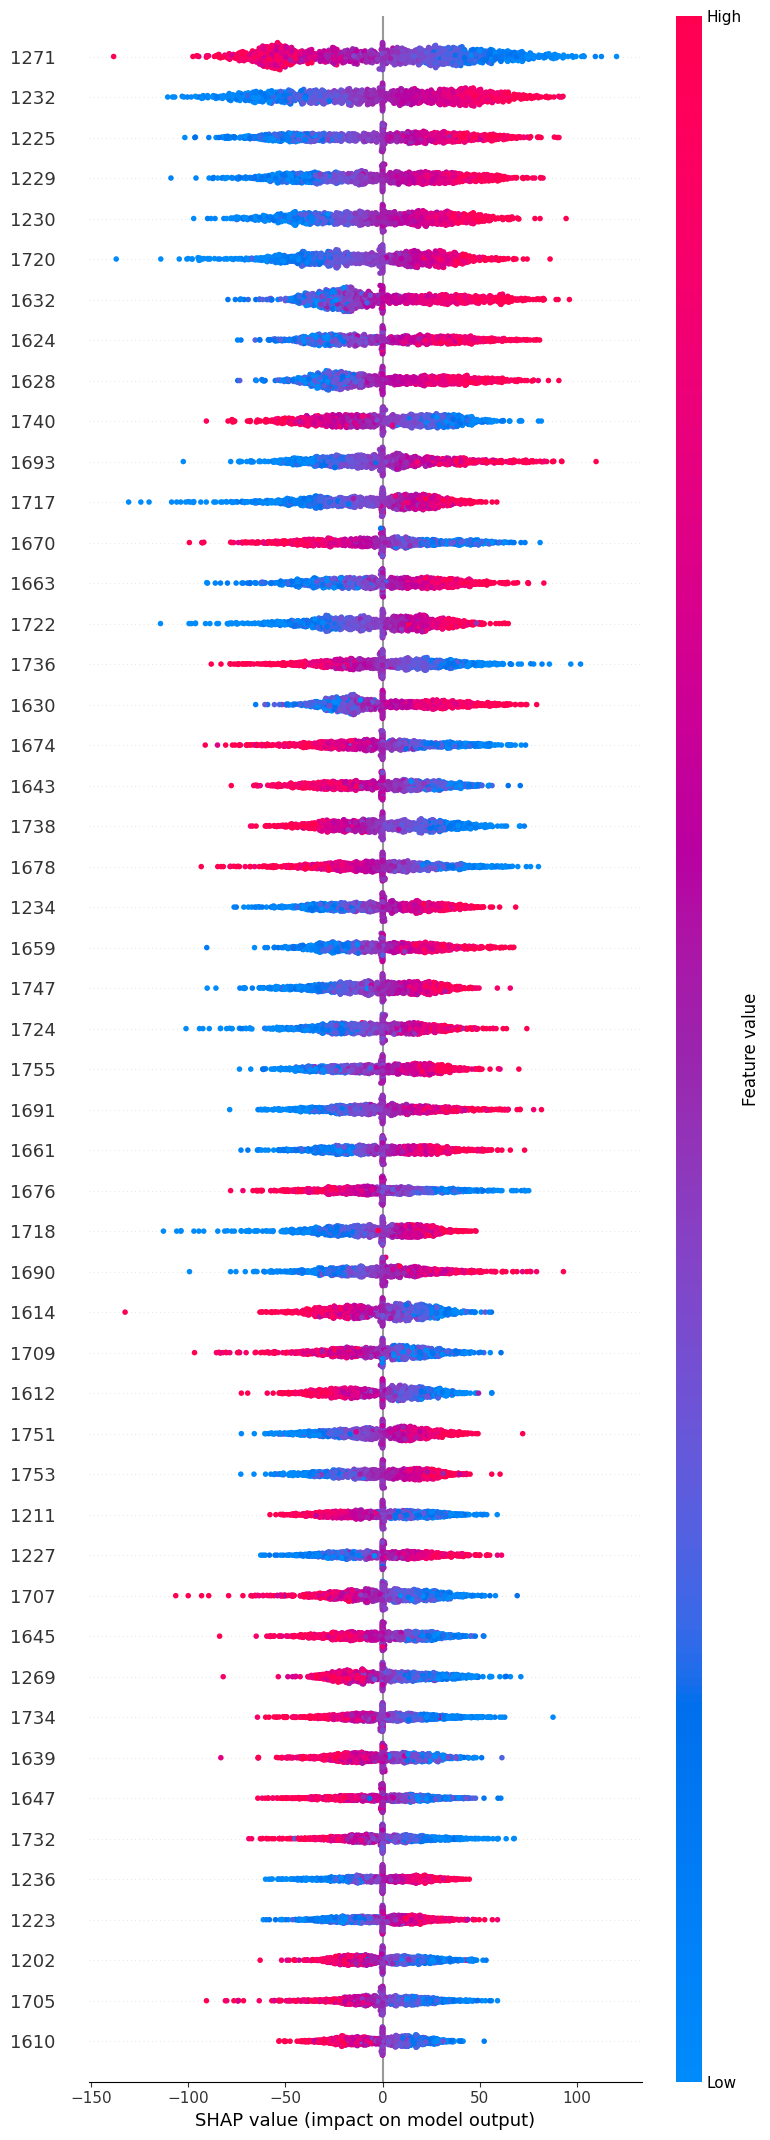

In [ ]:
shap.summary_plot(shap_values, features=features, feature_names=feature_labels, max_display=50)

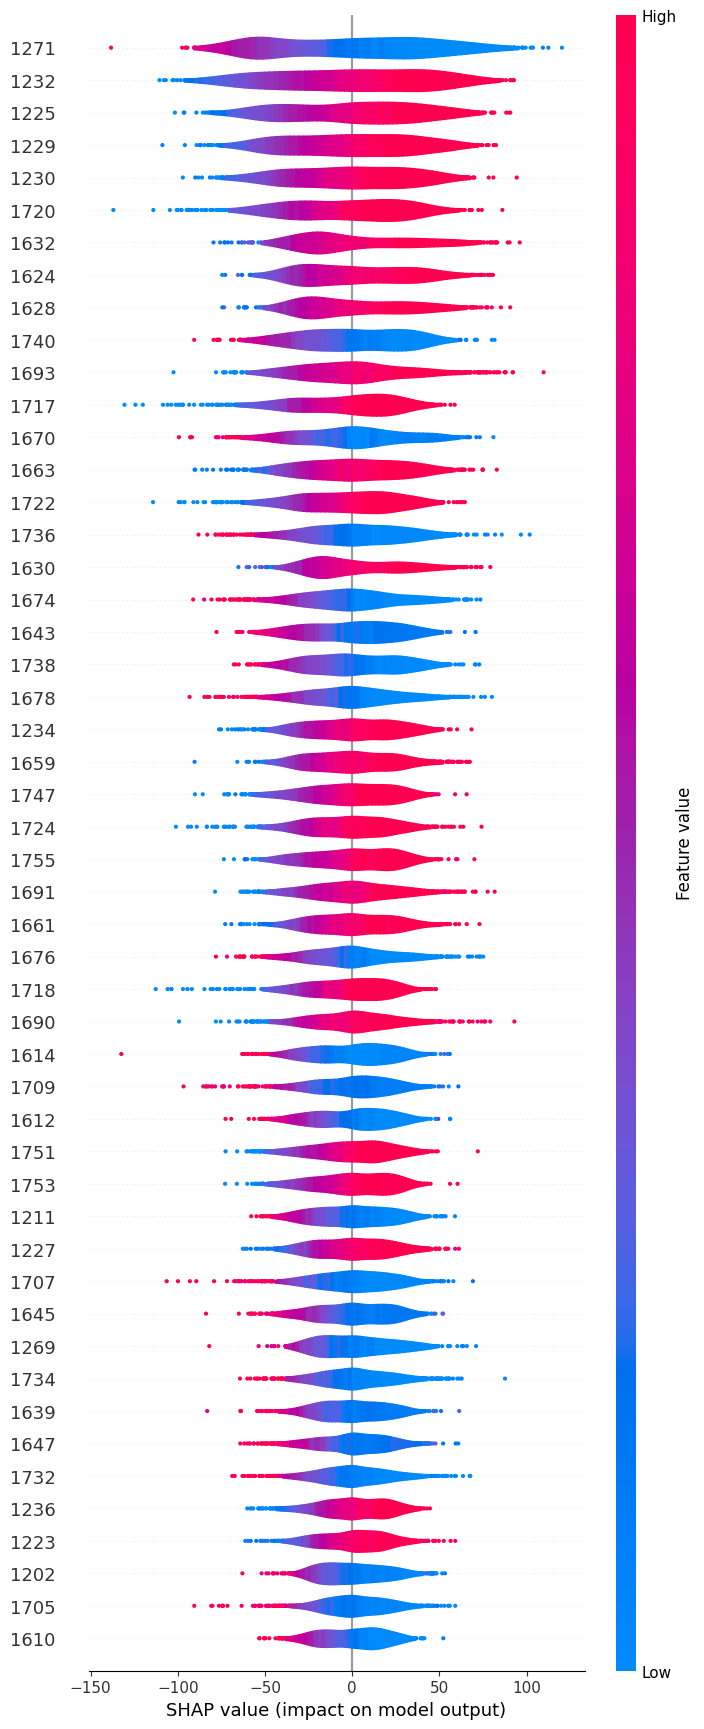

In [ ]:
shap.plots.violin(shap_values, features=features, feature_names=feature_labels, max_display=50, plot_type="violin")